## Breast Cancer Detection System


#### Import Libraries

In [1]:
import pandas as pd
import numpy as np

#### Import Dataset

In [2]:
dataset = pd.read_csv('Breast_Cancer.csv')
dataset.head()

,ID,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


#### Data Preprocessing

In [3]:
dataset.drop(dataset.columns[0], axis=1, inplace=True)
dataset.head(10)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,M
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,M
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,M
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,M
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,M


In [4]:
dataset['Diagnosis'].value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

#### Feature Selection


In [5]:
from sklearn.model_selection import train_test_split

In [6]:
diag_map = {'M': 1, 'B': 0}
dataset['Diagnosis'] = dataset['Diagnosis'].map(diag_map)
dataset.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [7]:
x = dataset[['radius1','perimeter1','area1','concavity1','concave_points1']]
y = dataset[['Diagnosis']]

In [9]:
x.head(5)

,radius1,perimeter1,area1,concavity1,concave_points1
0,17.99,122.80,1001.0,0.3001,0.14710
1,20.57,132.90,1326.0,0.0869,0.07017
2,19.69,130.00,1203.0,0.1974,0.12790
3,11.42,77.58,386.1,0.2414,0.10520
4,20.29,135.10,1297.0,0.1980,0.10430


In [12]:
y.head(3)

,Diagnosis
0,1
1,1
2,1


In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [17]:
x_train.head(5)

,radius1,perimeter1,area1,concavity1,concave_points1
68,9.029,58.79,250.5,0.31300,0.04375
181,21.090,142.70,1311.0,0.24870,0.14960
63,9.173,59.20,260.9,0.05988,0.02180
248,10.650,68.01,347.0,0.02379,0.01615
60,10.170,64.55,311.9,0.01084,0.01290


In [18]:
y_train.head(3)

,Diagnosis
68,0
181,1
63,0


In [19]:
x_test.head(5)

,radius1,perimeter1,area1,concavity1,concave_points1
204,12.47,81.09,481.9,0.08005,0.03821
70,18.94,123.60,1130.0,0.10800,0.07951
131,15.46,101.70,748.9,0.14660,0.08087
431,12.40,81.47,467.8,0.07741,0.02799
540,11.54,74.65,402.9,0.06737,0.02594


In [20]:
y_test.head(3)

,Diagnosis
204,0
70,1
131,1


### Different Models used are :
    1. Logistic Regression
    2. KNN
    3. Naive Bayes
    4. Decision Tree
    5. Random Forest
    6. SVM

#### LOGISTIC REGRESSION

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [23]:
# Model Training
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train, y_train)

/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000)

In [24]:

# Model Testing
y_pred = lr.predict(x_test)

In [25]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9298245614035088


In [27]:
# Cross Validation
scores = cross_val_score(lr, x_train, y_train, cv=10)
print("Cross Validation Scores : ", scores)
print("Average CV Score : ", scores.mean())

Cross Validation Scores :  [0.89130435 0.82608696 0.86956522 0.89130435 0.93478261 0.93333333
 0.88888889 0.82222222 0.86666667 0.86666667]
Average CV Score :  0.8790821256038648


/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Use

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[70  1]
 [ 7 36]]


In [29]:
# Precision
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.972972972972973


In [30]:
# Recall
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.8372093023255814


In [31]:
# F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9


#### KNN

In [32]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [33]:
# Model Training
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier()

In [34]:
# Model Testing
y_pred_knn = knn.predict(x_test)

In [35]:
# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)

Accuracy: 0.9210526315789473


In [36]:
# Cross Validation
cv_scores_knn = cross_val_score(knn, x_train, y_train, cv=10)
print("Cross Validation Scores:", cv_scores_knn)
print("Average CV Score:", cv_scores_knn.mean())

Cross Validation Scores: [0.89130435 0.84782609 0.86956522 0.82608696 0.95652174 0.91111111
 0.84444444 0.82222222 0.86666667 0.86666667]
Average CV Score: 0.8702415458937199


/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/neighbors/_classification.py:215: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/

In [37]:
# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm_knn)

Confusion Matrix:
 [[69  2]
 [ 7 36]]


In [38]:
# Precision
precision_knn = precision_score(y_test, y_pred_knn)
print("Precision:", precision_knn)

Precision: 0.9473684210526315


In [39]:
# Recall
recall_knn = recall_score(y_test, y_pred_knn)
print("Recall:", recall_knn)

Recall: 0.8372093023255814


In [40]:
# F1 Score
f1_knn = f1_score(y_test, y_pred_knn)
print("F1 Score:", f1_knn)

F1 Score: 0.8888888888888888


#### Naive Bayes



In [41]:
# Import Libraries
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [42]:
# Model Training
nb = GaussianNB()
nb.fit(x_train, y_train)

/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [43]:
# Model Testing
y_pred_nb = nb.predict(x_test)

In [44]:
# Accuracy Score
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy_nb)

Accuracy: 0.9473684210526315


In [45]:
# K-Fold Cross Validation
cv_scores_nb = cross_val_score(nb, x_train, y_train, cv=10)
print("Cross Validation Scores:", cv_scores_nb)
print("Average CV Score:", cv_scores_nb.mean())

Cross Validation Scores: [0.86956522 0.86956522 0.91304348 0.84782609 0.95652174 0.93333333
 0.91111111 0.86666667 0.91111111 0.84444444]
Average CV Score: 0.8923188405797102


/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Use

In [46]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix:\n", cm_nb)

Confusion Matrix:
 [[70  1]
 [ 5 38]]


In [47]:
# Precision
precision_nb = precision_score(y_test, y_pred_nb)
print("Precision:", precision_nb)

Precision: 0.9743589743589743


In [48]:
# Recall
recall_nb = recall_score(y_test, y_pred_nb)
print("Recall:", recall_nb)

Recall: 0.8837209302325582


In [49]:
# F1 Score
f1_nb = f1_score(y_test, y_pred_nb)
print("F1 Score:", f1_nb)

F1 Score: 0.9268292682926831


#### Decision Tree



In [50]:
# Import Libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score


In [51]:
# Model Training
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)


DecisionTreeClassifier(random_state=42)

In [52]:
# Model Testing
y_pred_dt = dt.predict(x_test)

In [53]:
# Accuracy Score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)

Accuracy: 0.8859649122807017


In [54]:
# K-Fold Cross Validation
cv_scores_dt = cross_val_score(dt, x_train, y_train, cv=10)
print("Cross Validation Scores:", cv_scores_dt)
print("Average CV Score:", cv_scores_dt.mean())

Cross Validation Scores: [0.93478261 0.86956522 0.97826087 0.86956522 0.91304348 0.91111111
 0.82222222 0.91111111 0.88888889 0.86666667]
Average CV Score: 0.8965217391304348


In [55]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix:\n", cm_dt)

Confusion Matrix:
 [[64  7]
 [ 6 37]]


In [56]:
# Precision
precision_dt = precision_score(y_test, y_pred_dt)
print("Precision:", precision_dt)


Precision: 0.8409090909090909


In [57]:
# Recall
recall_dt = recall_score(y_test, y_pred_dt)
print("Recall:", recall_dt)

Recall: 0.8604651162790697


In [58]:
# F1 Score
f1_dt = f1_score(y_test, y_pred_dt)
print("F1 Score:", f1_dt)

F1 Score: 0.8505747126436781


#### Random Forest


In [59]:
# Import Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [60]:
# Model Training
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)


/var/folders/kx/6gpn_y2919dgqrjn_k75j_2h0000gn/T/ipykernel_18229/662170201.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [61]:
# Model Testing
y_pred_rf = rf.predict(x_test)

In [62]:

# Accuracy Score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

Accuracy: 0.9385964912280702


In [63]:
# K-Fold Cross Validation
cv_scores_rf = cross_val_score(rf, x_train, y_train, cv=10)
print("Cross Validation Scores:", cv_scores_rf)
print("Average CV Score:", cv_scores_rf.mean())

/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for exa

Cross Validation Scores: [0.91304348 0.91304348 0.97826087 0.91304348 0.95652174 0.86666667
 0.88888889 0.95555556 0.95555556 0.91111111]
Average CV Score: 0.9251690821256039


/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:686: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)


In [64]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

Confusion Matrix:
 [[69  2]
 [ 5 38]]


In [65]:
# Precision
precision_rf = precision_score(y_test, y_pred_rf)
print("Precision:", precision_rf)


Precision: 0.95


In [66]:
# Recall
recall_rf = recall_score(y_test, y_pred_rf)
print("Recall:", recall_rf)

Recall: 0.8837209302325582


In [67]:
# F1 Score
f1_rf = f1_score(y_test, y_pred_rf)
print("F1 Score:", f1_rf)

F1 Score: 0.9156626506024096



#### SVM

In [68]:
# Import Libraries
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

In [69]:
# Model Training
svm = SVC(kernel='linear', random_state=42)
svm.fit(x_train, y_train)

/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', random_state=42)

In [70]:
# Model Testing
y_pred_svm = svm.predict(x_test)

In [71]:
# Accuracy Score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy_svm)

Accuracy: 0.9298245614035088


In [72]:
# K-Fold Cross Validation
cv_scores_svm = cross_val_score(svm, x_train, y_train, cv=10)
print("Cross Validation Scores:", cv_scores_svm)
print("Average CV Score:", cv_scores_svm.mean())

/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/namanpatel/Projects/AI_Projects/WildLife_Animal_Recognization_System/venv/lib/python3.9/site-packages/sklearn/utils/validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Use

Cross Validation Scores: [0.89130435 0.84782609 0.86956522 0.86956522 0.93478261 0.93333333
 0.88888889 0.84444444 0.91111111 0.86666667]
Average CV Score: 0.8857487922705314


In [73]:
# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

Confusion Matrix:
 [[70  1]
 [ 7 36]]


In [74]:
# Precision
precision_svm = precision_score(y_test, y_pred_svm)
print("Precision:", precision_svm)

Precision: 0.972972972972973


In [75]:
# Recall
recall_svm = recall_score(y_test, y_pred_svm)
print("Recall:", recall_svm)

Recall: 0.8372093023255814


In [76]:

# F1 Score
f1_svm = f1_score(y_test, y_pred_svm)
print("F1 Score:", f1_svm)

F1 Score: 0.9


### Comparing Different Model ALgorithms

In [77]:
results = {
    "Model": [
        "Logistic Regression",
        "KNN",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    
    "Accuracy": [
        accuracy,
        accuracy_knn,
        accuracy_nb,
        accuracy_dt,
        accuracy_rf,
        accuracy_svm
    ],
    
    "Precision": [
        precision,
        precision_knn,
        precision_nb,
        precision_dt,
        precision_rf,
        precision_svm
    ],
    
    "Recall": [
        recall,
        recall_knn,
        recall_nb,
        recall_dt,
        recall_rf,
        recall_svm
    ],
    
    "F1 Score": [
        f1,
        f1_knn,
        f1_nb,
        f1_dt,
        f1_rf,
        f1_svm
    ]
}

In [79]:
comparison_table = pd.DataFrame(results)
comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.929825,0.972973,0.837209,0.900000
1,KNN,0.921053,0.947368,0.837209,0.888889
2,Naive Bayes,0.947368,0.974359,0.883721,0.926829
3,Decision Tree,0.885965,0.840909,0.860465,0.850575
4,Random Forest,0.938596,0.950000,0.883721,0.915663
5,SVM,0.929825,0.972973,0.837209,0.900000


In [81]:
best_model = comparison_table.loc[comparison_table["Accuracy"].idxmax()]

print("Best Model Based on Accuracy:")
best_model

Best Model Based on Accuracy:


Model        Naive Bayes
Accuracy        0.947368
Precision       0.974359
Recall          0.883721
F1 Score        0.926829
Name: 2, dtype: object

In [89]:
comparison_table.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Naive Bayes,0.947368,0.974359,0.883721,0.926829
4,Random Forest,0.938596,0.950000,0.883721,0.915663
0,Logistic Regression,0.929825,0.972973,0.837209,0.900000
5,SVM,0.929825,0.972973,0.837209,0.900000
1,KNN,0.921053,0.947368,0.837209,0.888889
3,Decision Tree,0.885965,0.840909,0.860465,0.850575


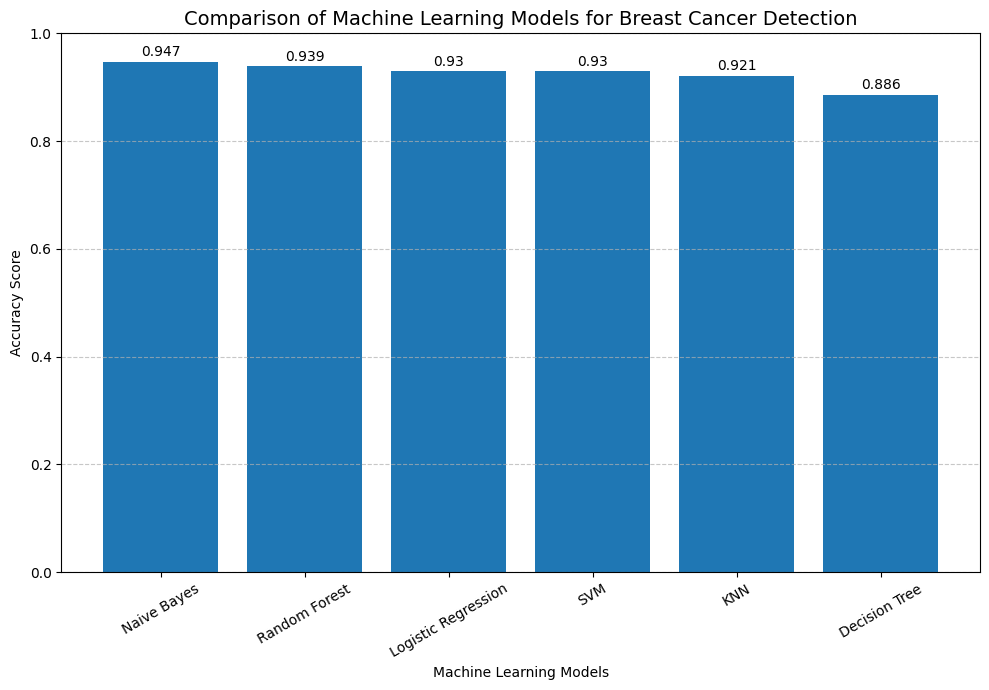

In [93]:
import matplotlib.pyplot as plt

# Sort models by accuracy
comparison_sorted = comparison_table.sort_values(by="Accuracy", ascending=False)
plt.figure(figsize=(10,7))
bars = plt.bar(comparison_sorted["Model"], comparison_sorted["Accuracy"])
plt.title("Comparison of Machine Learning Models for Breast Cancer Detection", fontsize=14)
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")
plt.ylim(0,1)

# Add accuracy values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval,3), 
             ha='center', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()